# Final dual-GPU: linear vs plateau con HPs ganadores de Optuna v2

Dos corridas finales en paralelo, una por GPU. Ambas usan los mismos HPs ganadores (idénticos en ambos studies); la única diferencia es el schedule de β.

| Run | GPU | β schedule | Tag |
|-----|-----|-----------|-----|
| Final-linear  | 0 | β crece linealmente 1e-6 → 0.0657 en 30 épocas | F_linear |
| Final-plateau | 1 | β crece linealmente 1e-6 → 0.0657 en 5 épocas, luego constante 25 épocas | F_plateau |

**HPs ganadores (Optuna v2, idénticos en ambos studies):**
- `lr_backbone` = 1.109e-06
- `lr_cvae` = 1.220e-03
- `beta_max` = 0.0657
- `lambda_l1` = 0.0147
- `lambda_var_patch` = 9.023
- `z_dim` = 128
- `cond_emb_dim` = 64
- `batch_size` = 32

**Setup**:
- Subsample: **10%**
- Épocas: **30**
- Loss: `(1-SSIM) + λ_L1·L1 + β·KLD + λ_var·MSE(var_per_patch_real, var_per_patch_gen)`
- Patches 4×4, stride 2 (361 patches por imagen 40×40)
- `generate()` con sampling de N(mu_p, exp(lv_p))
- `generate_mean()` disponible para métricas comparables y visualización determinista
- Split 70/15/15

**Tiempo esperado**: ~6h wall-clock (ambos en paralelo).


In [1]:
!pip install keras-hub -q

## Imports kernel principal (sin TF)

In [2]:
import os
import json
import time
import sys
import subprocess
import threading
import zipfile
import pickle
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
print(f"Python: {sys.version.split()[0]}")

Python: 3.12.12


## Cargar dataset, subsample 10% y cachear (split 70/15/15)

In [3]:
DATASET_PATH = "/kaggle/input/datasets/carloscanamejoy/dataset-spines-complete/dataset-united.npz"
KERAS_PATH = "/kaggle/input/datasets/carloscanamejoy/weights-vit-model/vit_model.keras"
WEIGHTS_TEMP = "/kaggle/working/pesos_temporales.weights.h5"
DATA_CACHE = "/kaggle/working/final_data.npz"

SUBSAMPLE_FRAC = 0.10

if not os.path.exists(DATA_CACHE):
    data = np.load(DATASET_PATH)
    imgs = data["img"].astype(np.float32)
    params = data["params"].astype(np.float32)

    N = len(imgs)
    rng = np.random.RandomState(SEED)
    sub_idx = rng.choice(N, size=int(N * SUBSAMPLE_FRAC), replace=False)

    imgs_sub = imgs[sub_idx]
    params_sub_raw = params[sub_idx]

    idx_all = np.arange(len(sub_idx))
    # 70/15/15: primero test_size=0.30, luego sobre el 30% test_size=0.50
    idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=SEED)
    idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED)

    scaler = MinMaxScaler()
    params_train = scaler.fit_transform(params_sub_raw[idx_train]).astype(np.float32)
    params_val = scaler.transform(params_sub_raw[idx_val]).astype(np.float32)
    params_test = scaler.transform(params_sub_raw[idx_test]).astype(np.float32)

    np.savez_compressed(
        DATA_CACHE,
        imgs_train=imgs_sub[idx_train], imgs_val=imgs_sub[idx_val],
        params_train=params_train, params_val=params_val,
        params_val_raw=params_sub_raw[idx_val],
    )
    with open("/kaggle/working/final_scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

    print(f"Dataset: {N:,} | Subsample 10%: {len(sub_idx):,}")
    print(f"Train: {len(idx_train):,} ({100*len(idx_train)/len(sub_idx):.0f}%)")
    print(f"Val:   {len(idx_val):,} ({100*len(idx_val)/len(sub_idx):.0f}%)")
    print(f"Test:  {len(idx_test):,} ({100*len(idx_test)/len(sub_idx):.0f}%)")
else:
    print(f"Cache existe: {DATA_CACHE}")
    cached = np.load(DATA_CACHE)
    print(f"  imgs_train: {cached['imgs_train'].shape}")
    print(f"  imgs_val:   {cached['imgs_val'].shape}")

Dataset: 218,256 | Subsample 10%: 21,825
Train: 15,277 (70%)
Val:   3,274 (15%)
Test:  3,274 (15%)


## Extraer pesos del ViT

In [4]:
if not os.path.exists(WEIGHTS_TEMP):
    with zipfile.ZipFile(KERAS_PATH, 'r') as z:
        z.extract("model.weights.h5", "/kaggle/working/")
        os.rename("/kaggle/working/model.weights.h5", WEIGHTS_TEMP)
    print(f"Weights extracted to {WEIGHTS_TEMP}")
else:
    print(f"Weights already at {WEIGHTS_TEMP}")

Weights extracted to /kaggle/working/pesos_temporales.weights.h5


## Worker script

Recibe HPs por JSON con `beta_schedule` y `warmup_epochs`. Entrena 30 épocas con la loss var-per-patch + sampling en `generate()`. Guarda pesos best/last + history.

In [5]:
WORKER_PATH = "/kaggle/working/final_worker.py"

WORKER_CODE = r'''
import os, sys, json, time, traceback
import numpy as np

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense, Input
import keras_hub

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

# args
cfg_path = sys.argv[1]
out_dir = sys.argv[2]
data_path = sys.argv[3]
weights_path = sys.argv[4]

with open(cfg_path) as f:
    cfg = json.load(f)

EXP_TAG = cfg["tag"]
LR_BACKBONE = cfg["lr_backbone"]
LR_CVAE = cfg["lr_cvae"]
BETA_MAX = cfg["beta_max"]
BETA_START = cfg["beta_start"]
LAMBDA_L1 = cfg["lambda_l1"]
LAMBDA_VAR_PATCH = cfg["lambda_var_patch"]
Z_DIM = cfg["z_dim"]
COND_EMB_DIM = cfg["cond_emb_dim"]
BATCH_SIZE = cfg["batch_size"]
EPOCHS = cfg["epochs"]
BETA_SCHEDULE = cfg["beta_schedule"]
WARMUP_EPOCHS = cfg.get("warmup_epochs", 0)
PATCH_SIZE = 4
PATCH_STRIDE = 2

print(f"[{EXP_TAG}] PID={os.getpid()} CUDA={os.environ.get('CUDA_VISIBLE_DEVICES','?')}", flush=True)
print(f"[{EXP_TAG}] GPUs visibles: {tf.config.list_physical_devices('GPU')}", flush=True)
print(f"[{EXP_TAG}] beta_schedule={BETA_SCHEDULE} warmup={WARMUP_EPOCHS}", flush=True)
print(f"[{EXP_TAG}] HPs: lr_bb={LR_BACKBONE:.2e} lr_cv={LR_CVAE:.2e} bmax={BETA_MAX:.4f}"
      f" l1={LAMBDA_L1:.4f} lvp={LAMBDA_VAR_PATCH:.2f} z={Z_DIM} ce={COND_EMB_DIM}", flush=True)

# datos
cached = np.load(data_path)
imgs_train = cached["imgs_train"]; imgs_val = cached["imgs_val"]
params_train = cached["params_train"]; params_val = cached["params_val"]
COND_DIM = params_train.shape[1]

def preprocess(img, param):
    img_vit = tf.image.resize(img, (224, 224))
    img_vit = tf.image.grayscale_to_rgb(img_vit)
    img_target = tf.image.resize(img, (40, 40))
    return img_vit, param, img_target

train_ds = (
    tf.data.Dataset.from_tensor_slices((imgs_train, params_train))
    .shuffle(10000, seed=SEED).batch(BATCH_SIZE)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((imgs_val, params_val))
    .batch(BATCH_SIZE)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

# CVAE
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, lv = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + eps * tf.exp(0.5 * lv)

class Encoder(layers.Layer):
    def __init__(self, z_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.fc1 = Dense(512, activation="silu"); self.fc2 = Dense(256, activation="silu")
        self.fc_mu = Dense(z_dim); self.fc_lv = Dense(z_dim); self.sampling = Sampling()
    def call(self, emb, ce):
        h = tf.concat([emb, ce], axis=-1); h = self.fc1(h); h = self.fc2(h)
        mu = self.fc_mu(h); lv = self.fc_lv(h)
        return mu, lv, self.sampling([mu, lv])

class Prior(layers.Layer):
    def __init__(self, z_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.cond_net = keras.Sequential([
            Dense(64, activation="silu"), Dense(128, activation="silu"),
            Dense(cond_emb_dim, activation="silu")])
        self.fc_mu = Dense(z_dim); self.fc_lv = Dense(z_dim)
    def call(self, y):
        ce = self.cond_net(y)
        return self.fc_mu(ce), self.fc_lv(ce), ce

class Decoder(layers.Layer):
    def __init__(self, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.fc_in = Dense(512*5*5, activation="silu"); self.reshape = layers.Reshape((5,5,512))
        self.up1 = layers.Conv2DTranspose(256, 4, strides=2, padding="same"); self.bn1 = layers.BatchNormalization()
        self.up2 = layers.Conv2DTranspose(128, 4, strides=2, padding="same"); self.bn2 = layers.BatchNormalization()
        self.up3 = layers.Conv2DTranspose(64, 4, strides=2, padding="same"); self.bn3 = layers.BatchNormalization()
        self.res1_c1 = layers.Conv2D(64, 3, padding="same"); self.res1_c2 = layers.Conv2D(64, 3, padding="same")
        self.res2_c1 = layers.Conv2D(64, 3, padding="same"); self.res2_c2 = layers.Conv2D(64, 3, padding="same")
        self.out_conv = layers.Conv2D(1, 1, activation="tanh")
    def call(self, z, ce, training=None):
        x = self.fc_in(tf.concat([z, ce], axis=-1)); x = self.reshape(x)
        x = tf.nn.silu(self.bn1(self.up1(x), training=training))
        x = tf.nn.silu(self.bn2(self.up2(x), training=training))
        x = tf.nn.silu(self.bn3(self.up3(x), training=training))
        h = tf.nn.silu(self.res1_c1(x)); x = tf.nn.silu(x + self.res1_c2(h))
        h = tf.nn.silu(self.res2_c1(x)); x = tf.nn.silu(x + self.res2_c2(h))
        return self.out_conv(x)

class CVAE_ViT(Model):
    def __init__(self, backbone, z_dim, cond_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.backbone = backbone; self.gap = GlobalAveragePooling1D()
        self.encoder = Encoder(z_dim, cond_emb_dim)
        self.prior = Prior(z_dim, cond_emb_dim)
        self.decoder = Decoder(cond_emb_dim)
    def call(self, inputs, training=None):
        img_vit, y = inputs
        emb = self.gap(self.backbone(img_vit, training=training))
        mu_p, lv_p, ce = self.prior(y)
        mu_q, lv_q, z = self.encoder(emb, ce)
        return self.decoder(z, ce, training=training), mu_q, lv_q, mu_p, lv_p
    def generate(self, y):
        mu_p, lv_p, ce = self.prior(y)
        eps = tf.random.normal(shape=tf.shape(mu_p))
        z = mu_p + eps * tf.exp(0.5 * lv_p)
        return self.decoder(z, ce, training=False)
    def generate_mean(self, y):
        mu_p, lv_p, ce = self.prior(y)
        return self.decoder(mu_p, ce, training=False)

def build_backbone():
    bb = keras_hub.models.ViTBackbone(
        image_shape=(224,224,3), patch_size=16, num_layers=12, num_heads=12,
        hidden_dim=768, mlp_dim=3072, use_class_token=True)
    _inp = Input(shape=(224,224,3))
    _x = bb(_inp); _x = GlobalAveragePooling1D()(_x); _x = Dense(8, activation="linear")(_x)
    _temp = Model(_inp, _x); _temp.load_weights(weights_path)
    del _temp
    enc_layer = bb.get_layer("vit_encoder")
    for block in enc_layer.encoder_layers[:8]:
        block.trainable = False
    return bb

def ssim_loss(y_true, y_pred):
    y_true_01 = (y_true + 1.0) / 2.0
    y_pred_01 = (y_pred + 1.0) / 2.0
    return 1.0 - tf.image.ssim(y_true_01, y_pred_01, max_val=1.0)

def var_per_patch(x, patch_size, stride):
    patches = tf.image.extract_patches(
        x, sizes=[1, patch_size, patch_size, 1],
        strides=[1, stride, stride, 1],
        rates=[1, 1, 1, 1], padding="VALID")
    B = tf.shape(patches)[0]
    n_patches = tf.shape(patches)[1] * tf.shape(patches)[2]
    flat = tf.reshape(patches, (B, n_patches, patch_size * patch_size))
    return tf.math.reduce_variance(flat, axis=-1)

def beta_for_epoch(epoch, total, schedule, beta_start, beta_max, warmup):
    if schedule == "linear":
        p = (epoch - 1) / max(1, total - 1)
        return beta_start + (beta_max - beta_start) * p
    elif schedule == "constant_after_warmup":
        if epoch <= warmup:
            p = (epoch - 1) / max(1, warmup - 1)
            return beta_start + (beta_max - beta_start) * p
        else:
            return beta_max
    else:
        raise ValueError(schedule)

# training
ckpt_best = os.path.join(out_dir, f"weights_best_{EXP_TAG}.weights.h5")
ckpt_last = os.path.join(out_dir, f"weights_last_{EXP_TAG}.weights.h5")
hist_path = os.path.join(out_dir, f"history_{EXP_TAG}.json")
status_path = os.path.join(out_dir, f"status_{EXP_TAG}.json")

result = {"tag": EXP_TAG, "status": "running", "best_val_gen": None, "history": [], "err": None}

try:
    model = CVAE_ViT(build_backbone(), z_dim=Z_DIM, cond_dim=COND_DIM, cond_emb_dim=COND_EMB_DIM)
    _ = model([tf.zeros((1,224,224,3)), tf.zeros((1,COND_DIM))], training=False)
    print(f"[{EXP_TAG}] CVAE params: {model.count_params():,}", flush=True)

    opt_bb = keras.optimizers.Adam(learning_rate=LR_BACKBONE)
    opt_cv = keras.optimizers.Adam(learning_rate=LR_CVAE)
    bb_vars = model.backbone.trainable_variables
    cv_vars = (model.encoder.trainable_variables +
               model.prior.trainable_variables +
               model.decoder.trainable_variables +
               model.gap.trainable_variables)

    L1_C = tf.constant(LAMBDA_L1, dtype=tf.float32)
    LVP = tf.constant(LAMBDA_VAR_PATCH, dtype=tf.float32)

    @tf.function
    def train_step(img_vit, y, img_target, beta):
        with tf.GradientTape() as tape:
            x_hat, mu_q, lv_q, mu_p, lv_p = model([img_vit, y], training=True)
            ssim_val = tf.reduce_mean(ssim_loss(img_target, x_hat))
            l1_val = tf.reduce_mean(tf.abs(x_hat - img_target))
            recon = ssim_val + L1_C * l1_val
            vp_real = var_per_patch(img_target, PATCH_SIZE, PATCH_STRIDE)
            vp_gen = var_per_patch(x_hat, PATCH_SIZE, PATCH_STRIDE)
            patch_loss = tf.reduce_mean(tf.square(vp_real - vp_gen))
            vq = tf.exp(lv_q); vp = tf.exp(lv_p)
            kld = tf.reduce_mean(0.5 * (lv_p - lv_q + (vq + tf.square(mu_q - mu_p)) / vp - 1.0))
            loss = recon + LVP * patch_loss + beta * kld

        grads = tape.gradient(loss, bb_vars + cv_vars)
        gbb = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in grads[:len(bb_vars)]]
        gcv = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in grads[len(bb_vars):]]
        opt_bb.apply_gradients([(g,v) for g,v in zip(gbb, bb_vars) if g is not None])
        opt_cv.apply_gradients([(g,v) for g,v in zip(gcv, cv_vars) if g is not None])
        return loss, recon, kld, ssim_val, l1_val, patch_loss

    @tf.function
    def val_step(img_vit, y, img_target):
        x_hat, mu_q, lv_q, mu_p, lv_p = model([img_vit, y], training=False)
        ssim_val = tf.reduce_mean(ssim_loss(img_target, x_hat))
        l1_val = tf.reduce_mean(tf.abs(x_hat - img_target))
        recon = ssim_val + L1_C * l1_val

        vq = tf.exp(lv_q); vp = tf.exp(lv_p)
        kl_per_dim = 0.5 * (lv_p - lv_q + (vq + tf.square(mu_q - mu_p)) / vp - 1.0)
        kld = tf.reduce_mean(kl_per_dim)

        x_gen_s = model.generate(y)
        ssim_gen_s = tf.reduce_mean(ssim_loss(img_target, x_gen_s))
        l1_gen_s = tf.reduce_mean(tf.abs(x_gen_s - img_target))
        gen_sample = ssim_gen_s + L1_C * l1_gen_s

        x_gen_m = model.generate_mean(y)
        ssim_gen_m = tf.reduce_mean(ssim_loss(img_target, x_gen_m))
        l1_gen_m = tf.reduce_mean(tf.abs(x_gen_m - img_target))
        gen_mean = ssim_gen_m + L1_C * l1_gen_m

        v_real = tf.reduce_mean(tf.math.reduce_variance(img_target, axis=[1,2,3]))
        v_recon = tf.reduce_mean(tf.math.reduce_variance(x_hat, axis=[1,2,3]))
        v_gen_s = tf.reduce_mean(tf.math.reduce_variance(x_gen_s, axis=[1,2,3]))
        v_gen_m = tf.reduce_mean(tf.math.reduce_variance(x_gen_m, axis=[1,2,3]))

        vp_real = var_per_patch(img_target, PATCH_SIZE, PATCH_STRIDE)
        vp_gen_s = var_per_patch(x_gen_s, PATCH_SIZE, PATCH_STRIDE)
        patch_var_loss_gen = tf.reduce_mean(tf.square(vp_real - vp_gen_s))

        active = tf.reduce_mean(tf.cast(tf.reduce_mean(kl_per_dim, axis=0) > 0.01, tf.float32))
        var_q = tf.reduce_mean(vq)

        return (recon, kld, gen_sample, gen_mean, ssim_gen_s, l1_gen_s, ssim_gen_m, l1_gen_m,
                v_real, v_recon, v_gen_s, v_gen_m, patch_var_loss_gen, active, var_q)

    best_gen = float("inf")
    for epoch in range(1, EPOCHS+1):
        t0 = time.time()
        beta = beta_for_epoch(epoch, EPOCHS, BETA_SCHEDULE, BETA_START, BETA_MAX, WARMUP_EPOCHS)
        beta_t = tf.constant(beta, dtype=tf.float32)

        tl = tr = tk = ts = tl1_v = tpv = 0.0; nb = 0
        for img_vit, param, img_orig in train_ds:
            loss, rec, kld, sv, l1v, pv = train_step(img_vit, param, img_orig, beta_t)
            tl += float(loss); tr += float(rec); tk += float(kld)
            ts += float(sv); tl1_v += float(l1v); tpv += float(pv); nb += 1
        tl /= nb; tr /= nb; tk /= nb; ts /= nb; tl1_v /= nb; tpv /= nb

        agg = np.zeros(15); nv = 0
        for img_vit, param, img_orig in val_ds:
            outs = val_step(img_vit, param, img_orig)
            agg += np.array([float(o) for o in outs]); nv += 1
        agg /= nv
        (vr, vk, vgs, vgm, vsgs, vl1gs, vsgm, vl1gm,
         v_real, v_recon, v_gen_s, v_gen_m, pvl_g, va, vq_m) = agg

        if not (np.isfinite(vgs) and np.isfinite(tl)):
            result["status"] = "nan"
            result["err"] = f"NaN en epoch {epoch}"
            break

        tag = ""
        if vgs < best_gen:
            best_gen = vgs
            model.save_weights(ckpt_best)
            tag = " *"

        result["history"].append({
            "epoch": epoch, "beta": beta,
            "train_loss": tl, "train_recon": tr, "train_kld": tk,
            "train_ssim": ts, "train_l1": tl1_v, "train_patch_var": tpv,
            "val_recon": vr, "val_kld": vk,
            "val_gen_sample": vgs, "val_gen_mean": vgm,
            "val_ssim_gen_sample": vsgs, "val_l1_gen_sample": vl1gs,
            "val_ssim_gen_mean": vsgm, "val_l1_gen_mean": vl1gm,
            "val_var_real": v_real, "val_var_recon": v_recon,
            "val_var_gen_sample": v_gen_s, "val_var_gen_mean": v_gen_m,
            "val_patch_var_loss_gen": pvl_g,
            "kl_active": va, "var_q": vq_m,
            "time_s": time.time()-t0,
        })

        print(f"[{EXP_TAG}] Ep[{epoch:2d}/{EPOCHS}] b={beta:.4f}"
              f" | rec={tr:.4f} kld={tk:.4f} ssim={ts:.4f} l1={tl1_v:.4f} pV={tpv:.4f}"
              f" | Vr={vr:.4f} Vgs={vgs:.4f} Vgm={vgm:.4f}"
              f" | Vvar(R={v_real:.3f} r={v_recon:.3f} gs={v_gen_s:.3f} gm={v_gen_m:.3f})"
              f" | act={va:.2f} vQ={vq_m:.3f} | {time.time()-t0:.0f}s" + tag, flush=True)

        with open(hist_path, "w") as f:
            json.dump(result["history"], f)

    if result["status"] != "nan":
        result["status"] = "ok"
        result["best_val_gen"] = best_gen
        model.save_weights(ckpt_last)

except tf.errors.ResourceExhaustedError as e:
    result["status"] = "oom"
    result["err"] = str(e)[:400]
except Exception as e:
    result["status"] = "error"
    result["err"] = f"{type(e).__name__}: {str(e)[:300]}\n{traceback.format_exc()[:1500]}"

with open(status_path, "w") as f:
    json.dump(result, f, indent=2)

print(f"[{EXP_TAG}] WORKER DONE: status={result['status']} best={result.get('best_val_gen')}", flush=True)
'''

with open(WORKER_PATH, "w") as f:
    f.write(WORKER_CODE)
print(f"Worker escrito en {WORKER_PATH} ({os.path.getsize(WORKER_PATH)} bytes)")

Worker escrito en /kaggle/working/final_worker.py (14682 bytes)


## Configs (mismos HPs, schedule de β distinto)

In [6]:
OUT_DIR = "/kaggle/working/final_runs"
os.makedirs(OUT_DIR, exist_ok=True)

# HPs ganadores de Optuna v2 (idénticos en ambos studies)
BASE = {
    "lr_backbone": 1.108660525448588e-06,
    "lr_cvae":     0.0012195373849248558,
    "beta_max":    0.06573922697499271,
    "beta_start":  1e-6,
    "lambda_l1":   0.014748723028263022,
    "lambda_var_patch": 9.023346061020113,
    "z_dim":       128,
    "cond_emb_dim": 64,
    "batch_size":  32,
    "epochs":      30,
}

EXP_LIN = {**BASE, "tag": "F_linear",
           "beta_schedule": "linear", "warmup_epochs": 0}

EXP_PLA = {**BASE, "tag": "F_plateau",
           "beta_schedule": "constant_after_warmup", "warmup_epochs": 5}

cfg_lin = os.path.join(OUT_DIR, "cfg_linear.json")
cfg_pla = os.path.join(OUT_DIR, "cfg_plateau.json")
with open(cfg_lin, "w") as f: json.dump(EXP_LIN, f, indent=2)
with open(cfg_pla, "w") as f: json.dump(EXP_PLA, f, indent=2)

print("EXP F_linear:");  print(json.dumps(EXP_LIN, indent=2))
print("\nEXP F_plateau:"); print(json.dumps(EXP_PLA, indent=2))

EXP F_linear:
{
  "lr_backbone": 1.108660525448588e-06,
  "lr_cvae": 0.0012195373849248558,
  "beta_max": 0.06573922697499271,
  "beta_start": 1e-06,
  "lambda_l1": 0.014748723028263022,
  "lambda_var_patch": 9.023346061020113,
  "z_dim": 128,
  "cond_emb_dim": 64,
  "batch_size": 32,
  "epochs": 30,
  "tag": "F_linear",
  "beta_schedule": "linear",
  "warmup_epochs": 0
}

EXP F_plateau:
{
  "lr_backbone": 1.108660525448588e-06,
  "lr_cvae": 0.0012195373849248558,
  "beta_max": 0.06573922697499271,
  "beta_start": 1e-06,
  "lambda_l1": 0.014748723028263022,
  "lambda_var_patch": 9.023346061020113,
  "z_dim": 128,
  "cond_emb_dim": 64,
  "batch_size": 32,
  "epochs": 30,
  "tag": "F_plateau",
  "beta_schedule": "constant_after_warmup",
  "warmup_epochs": 5
}


## Lanzar ambos workers en paralelo

In [7]:
def stream_output(proc, tag):
    for line in iter(proc.stdout.readline, ''):
        if line:
            print(line.rstrip(), flush=True)
    proc.stdout.close()


def launch_worker(cfg_path, gpu_id, tag):
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = str(gpu_id)
    env["TF_CPP_MIN_LOG_LEVEL"] = "2"
    cmd = [sys.executable, WORKER_PATH, cfg_path, OUT_DIR, DATA_CACHE, WEIGHTS_TEMP]
    proc = subprocess.Popen(
        cmd, env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1,
    )
    th = threading.Thread(target=stream_output, args=(proc, tag), daemon=True)
    th.start()
    return proc, th


print("Lanzando F_linear en GPU 0...")
proc_lin, th_lin = launch_worker(cfg_lin, gpu_id=0, tag="F_linear")
time.sleep(3)
print("Lanzando F_plateau en GPU 1...")
proc_pla, th_pla = launch_worker(cfg_pla, gpu_id=1, tag="F_plateau")

t_start = time.time()
print(f"\n{'='*70}\nAmbos corriendo (10% subsample, 30 ep). Esperando...\n{'='*70}\n")

rc_lin = proc_lin.wait()
rc_pla = proc_pla.wait()
th_lin.join(timeout=10); th_pla.join(timeout=10)

elapsed = (time.time() - t_start) / 60
print(f"\n{'='*70}\nAmbos terminaron en {elapsed:.1f} min ({elapsed/60:.2f}h)")
print(f"  rc_lin={rc_lin} rc_pla={rc_pla}\n{'='*70}")

Lanzando F_linear en GPU 0...
Lanzando F_plateau en GPU 1...

Ambos corriendo (10% subsample, 30 ep). Esperando...

2026-04-27 21:28:46.836253: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-27 21:28:46.844779: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered

E0000 00:00:1777325327.238863      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777325327.238708      62 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777325327.353038      62 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to registe

## Status final

In [8]:
for tag in ["F_linear", "F_plateau"]:
    sp = os.path.join(OUT_DIR, f"status_{tag}.json")
    if os.path.exists(sp):
        with open(sp) as f: s = json.load(f)
        print(f"[{tag}] status={s['status']}  best_val_gen={s.get('best_val_gen')}")
        if s.get("err"):
            print(f"  ERR: {s['err'][:400]}")
    else:
        print(f"[{tag}] sin status")

[F_linear] status=ok  best_val_gen=0.8795198537770984
[F_plateau] status=ok  best_val_gen=0.8512639675325561


## Curvas comparativas

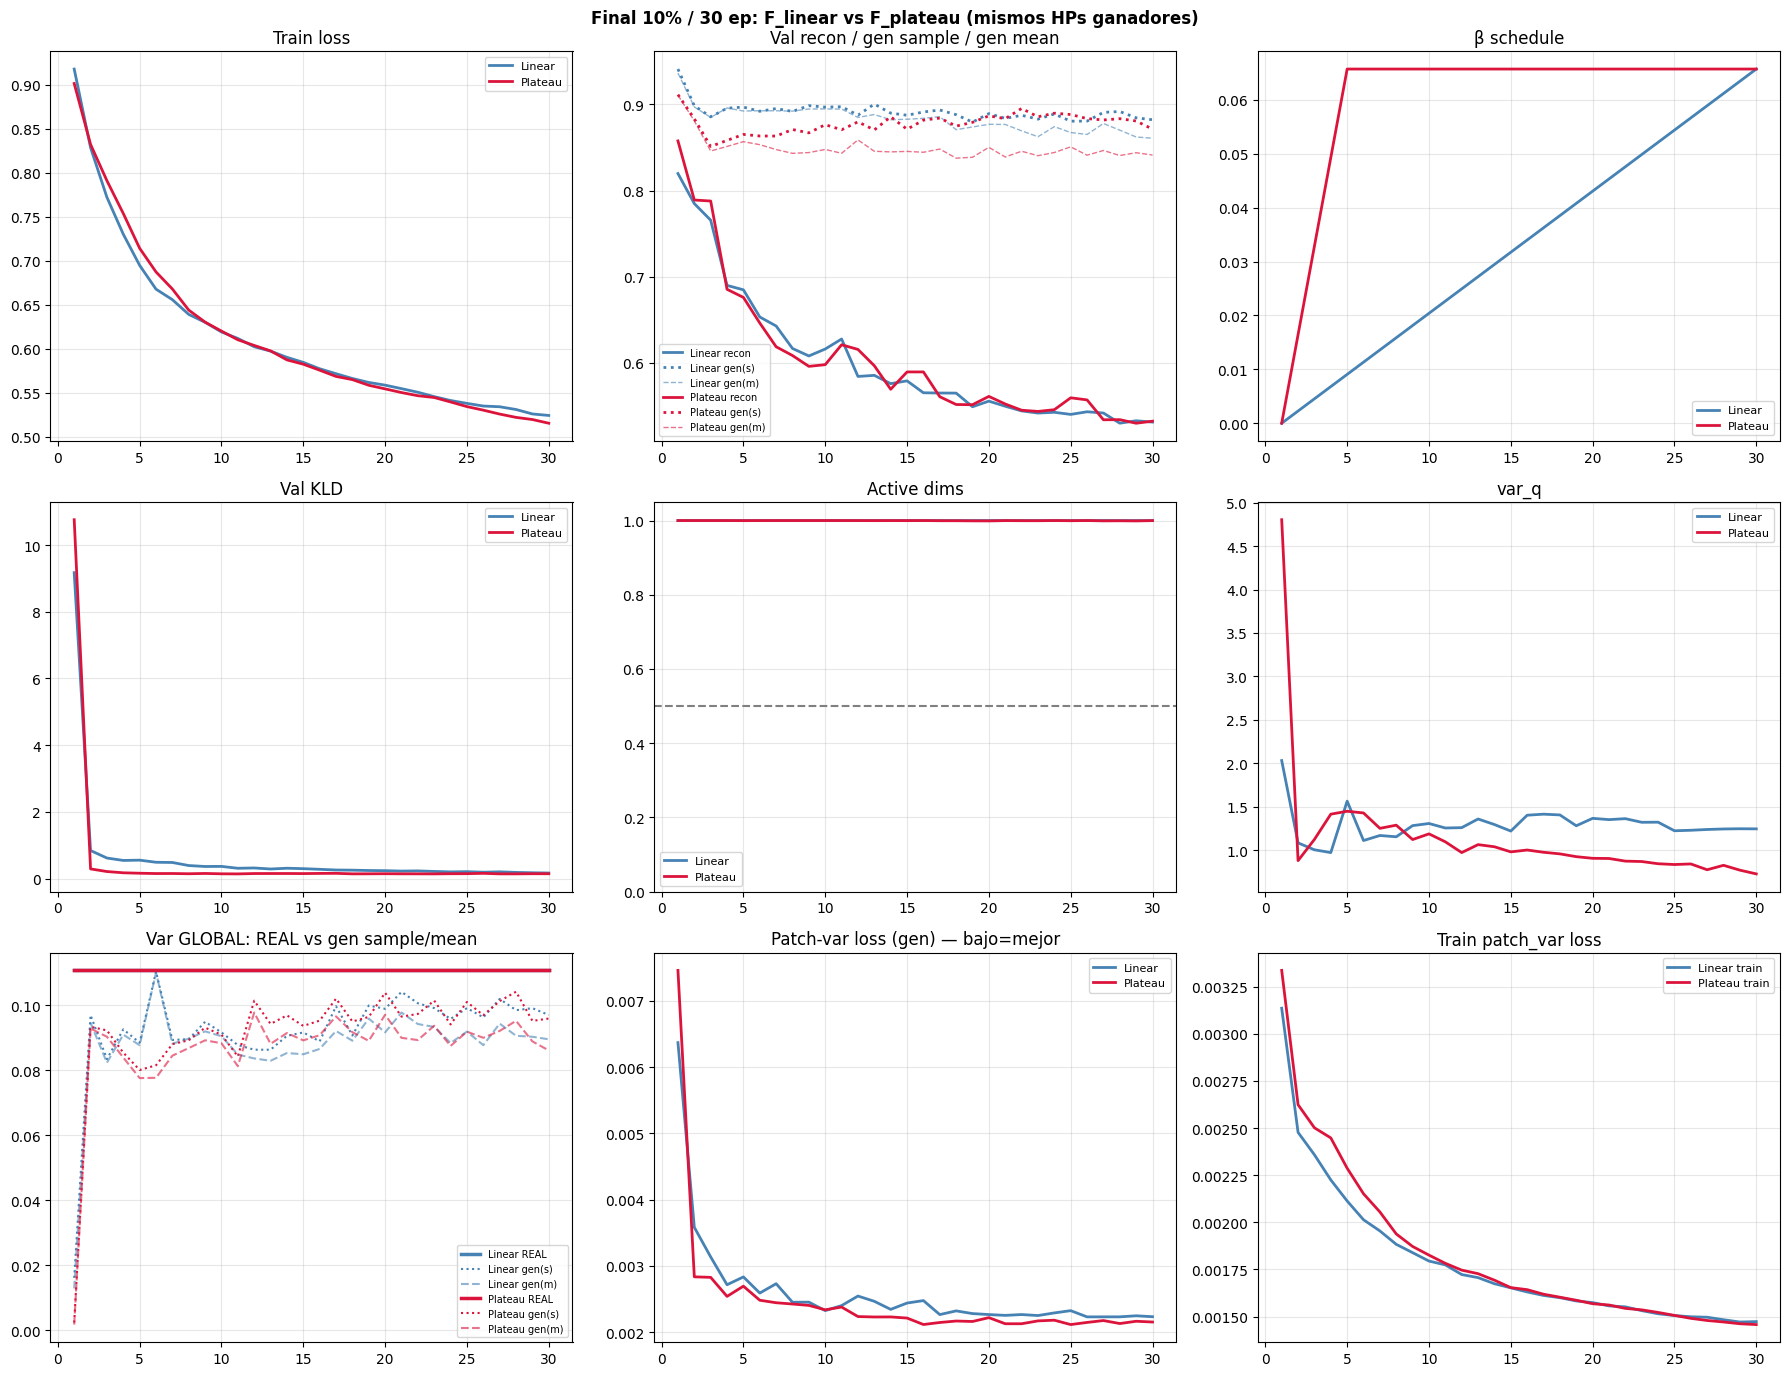

In [9]:
histories = {}
for tag in ["F_linear", "F_plateau"]:
    hp = os.path.join(OUT_DIR, f"history_{tag}.json")
    if os.path.exists(hp):
        with open(hp) as f:
            histories[tag] = json.load(f)

if not histories:
    print("Sin histories.")
else:
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    fig.suptitle("Final 10% / 30 ep: F_linear vs F_plateau (mismos HPs ganadores)",
                 fontsize=12, fontweight="bold")

    colors = {"F_linear": "steelblue", "F_plateau": "crimson"}
    labels = {"F_linear": "Linear", "F_plateau": "Plateau"}

    for tag, hist in histories.items():
        ep = [h["epoch"] for h in hist]
        c = colors[tag]; lb = labels[tag]

        axes[0,0].plot(ep, [h["train_loss"] for h in hist], color=c, lw=2, label=lb)
        axes[0,1].plot(ep, [h["val_recon"] for h in hist], color=c, lw=2, label=f"{lb} recon")
        axes[0,1].plot(ep, [h["val_gen_sample"] for h in hist], color=c, lw=2, ls=":", label=f"{lb} gen(s)")
        axes[0,1].plot(ep, [h["val_gen_mean"] for h in hist], color=c, lw=1, ls="--", alpha=0.6, label=f"{lb} gen(m)")
        axes[0,2].plot(ep, [h["beta"] for h in hist], color=c, lw=2, label=lb)

        axes[1,0].plot(ep, [h["val_kld"] for h in hist], color=c, lw=2, label=lb)
        axes[1,1].plot(ep, [h["kl_active"] for h in hist], color=c, lw=2, label=lb)
        axes[1,2].plot(ep, [h["var_q"] for h in hist], color=c, lw=2, label=lb)

        axes[2,0].plot(ep, [h["val_var_real"] for h in hist], color=c, lw=2.5, label=f"{lb} REAL")
        axes[2,0].plot(ep, [h["val_var_gen_sample"] for h in hist], color=c, lw=1.5, ls=":", label=f"{lb} gen(s)")
        axes[2,0].plot(ep, [h["val_var_gen_mean"] for h in hist], color=c, lw=1.5, ls="--", alpha=0.6, label=f"{lb} gen(m)")
        axes[2,1].plot(ep, [h["val_patch_var_loss_gen"] for h in hist], color=c, lw=2, label=lb)
        axes[2,2].plot(ep, [h["train_patch_var"] for h in hist], color=c, lw=2, label=f"{lb} train")

    axes[0,0].set_title("Train loss"); axes[0,0].legend(fontsize=8); axes[0,0].grid(alpha=0.3)
    axes[0,1].set_title("Val recon / gen sample / gen mean"); axes[0,1].legend(fontsize=7); axes[0,1].grid(alpha=0.3)
    axes[0,2].set_title("β schedule"); axes[0,2].legend(fontsize=8); axes[0,2].grid(alpha=0.3)
    axes[1,0].set_title("Val KLD"); axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)
    axes[1,1].set_title("Active dims"); axes[1,1].set_ylim(0, 1.05); axes[1,1].axhline(0.5, color="gray", ls="--"); axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)
    axes[1,2].set_title("var_q"); axes[1,2].legend(fontsize=8); axes[1,2].grid(alpha=0.3)
    axes[2,0].set_title("Var GLOBAL: REAL vs gen sample/mean"); axes[2,0].legend(fontsize=7); axes[2,0].grid(alpha=0.3)
    axes[2,1].set_title("Patch-var loss (gen) — bajo=mejor"); axes[2,1].legend(fontsize=8); axes[2,1].grid(alpha=0.3)
    axes[2,2].set_title("Train patch_var loss"); axes[2,2].legend(fontsize=8); axes[2,2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("/kaggle/working/final_curves.png", dpi=100)
    plt.show()

## Cargar TF en kernel para inferencia

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense, Input
import keras_hub

for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

class Sampling(layers.Layer):
    def call(self, inputs):
        mu, lv = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + eps * tf.exp(0.5 * lv)

class Encoder(layers.Layer):
    def __init__(self, z_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.fc1 = Dense(512, activation="silu"); self.fc2 = Dense(256, activation="silu")
        self.fc_mu = Dense(z_dim); self.fc_lv = Dense(z_dim); self.sampling = Sampling()
    def call(self, emb, ce):
        h = tf.concat([emb, ce], axis=-1); h = self.fc1(h); h = self.fc2(h)
        mu = self.fc_mu(h); lv = self.fc_lv(h)
        return mu, lv, self.sampling([mu, lv])

class Prior(layers.Layer):
    def __init__(self, z_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.cond_net = keras.Sequential([
            Dense(64, activation="silu"), Dense(128, activation="silu"),
            Dense(cond_emb_dim, activation="silu")])
        self.fc_mu = Dense(z_dim); self.fc_lv = Dense(z_dim)
    def call(self, y):
        ce = self.cond_net(y)
        return self.fc_mu(ce), self.fc_lv(ce), ce

class Decoder(layers.Layer):
    def __init__(self, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.fc_in = Dense(512*5*5, activation="silu"); self.reshape = layers.Reshape((5,5,512))
        self.up1 = layers.Conv2DTranspose(256, 4, strides=2, padding="same"); self.bn1 = layers.BatchNormalization()
        self.up2 = layers.Conv2DTranspose(128, 4, strides=2, padding="same"); self.bn2 = layers.BatchNormalization()
        self.up3 = layers.Conv2DTranspose(64, 4, strides=2, padding="same"); self.bn3 = layers.BatchNormalization()
        self.res1_c1 = layers.Conv2D(64, 3, padding="same"); self.res1_c2 = layers.Conv2D(64, 3, padding="same")
        self.res2_c1 = layers.Conv2D(64, 3, padding="same"); self.res2_c2 = layers.Conv2D(64, 3, padding="same")
        self.out_conv = layers.Conv2D(1, 1, activation="tanh")
    def call(self, z, ce, training=None):
        x = self.fc_in(tf.concat([z, ce], axis=-1)); x = self.reshape(x)
        x = tf.nn.silu(self.bn1(self.up1(x), training=training))
        x = tf.nn.silu(self.bn2(self.up2(x), training=training))
        x = tf.nn.silu(self.bn3(self.up3(x), training=training))
        h = tf.nn.silu(self.res1_c1(x)); x = tf.nn.silu(x + self.res1_c2(h))
        h = tf.nn.silu(self.res2_c1(x)); x = tf.nn.silu(x + self.res2_c2(h))
        return self.out_conv(x)

class CVAE_ViT(Model):
    def __init__(self, backbone, z_dim, cond_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.backbone = backbone; self.gap = GlobalAveragePooling1D()
        self.encoder = Encoder(z_dim, cond_emb_dim)
        self.prior = Prior(z_dim, cond_emb_dim)
        self.decoder = Decoder(cond_emb_dim)
    def call(self, inputs, training=None):
        img_vit, y = inputs
        emb = self.gap(self.backbone(img_vit, training=training))
        mu_p, lv_p, ce = self.prior(y)
        mu_q, lv_q, z = self.encoder(emb, ce)
        return self.decoder(z, ce, training=training), mu_q, lv_q, mu_p, lv_p
    def generate(self, y):
        mu_p, lv_p, ce = self.prior(y)
        eps = tf.random.normal(shape=tf.shape(mu_p))
        z = mu_p + eps * tf.exp(0.5 * lv_p)
        return self.decoder(z, ce, training=False)
    def generate_mean(self, y):
        mu_p, lv_p, ce = self.prior(y)
        return self.decoder(mu_p, ce, training=False)

def build_eval_model(z_dim, cond_emb_dim):
    bb = keras_hub.models.ViTBackbone(
        image_shape=(224,224,3), patch_size=16, num_layers=12, num_heads=12,
        hidden_dim=768, mlp_dim=3072, use_class_token=True)
    m = CVAE_ViT(bb, z_dim=z_dim, cond_dim=8, cond_emb_dim=cond_emb_dim)
    _ = m([tf.zeros((1,224,224,3)), tf.zeros((1,8))], training=False)
    return m

cached = np.load(DATA_CACHE)
imgs_val = cached["imgs_val"]
params_val = cached["params_val"]
params_val_raw = cached["params_val_raw"]

T_col = params_val_raw[:, 0]
order = np.argsort(T_col)
sel_idx = order[np.linspace(0, len(order)-1, 8).astype(int)]
print(f"Seleccionados (ordenados por T): T={T_col[sel_idx]}")

2026-04-28 03:29:59.027137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777346999.046898      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777346999.054868      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777346999.074656      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777346999.074676      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777346999.074679      22 computation_placer.cc:177] computation placer alr

Seleccionados (ordenados por T): T=[ 0.2  1.1  2.2  3.2  4.5  6.1  8.5 20. ]


## Grillas: Orig + Recon + Mean + 5 samples

I0000 00:00:1777347009.882768      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777347009.887974      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1777347013.396535      22 cuda_dnn.cc:529] Loaded cuDNN version 91002


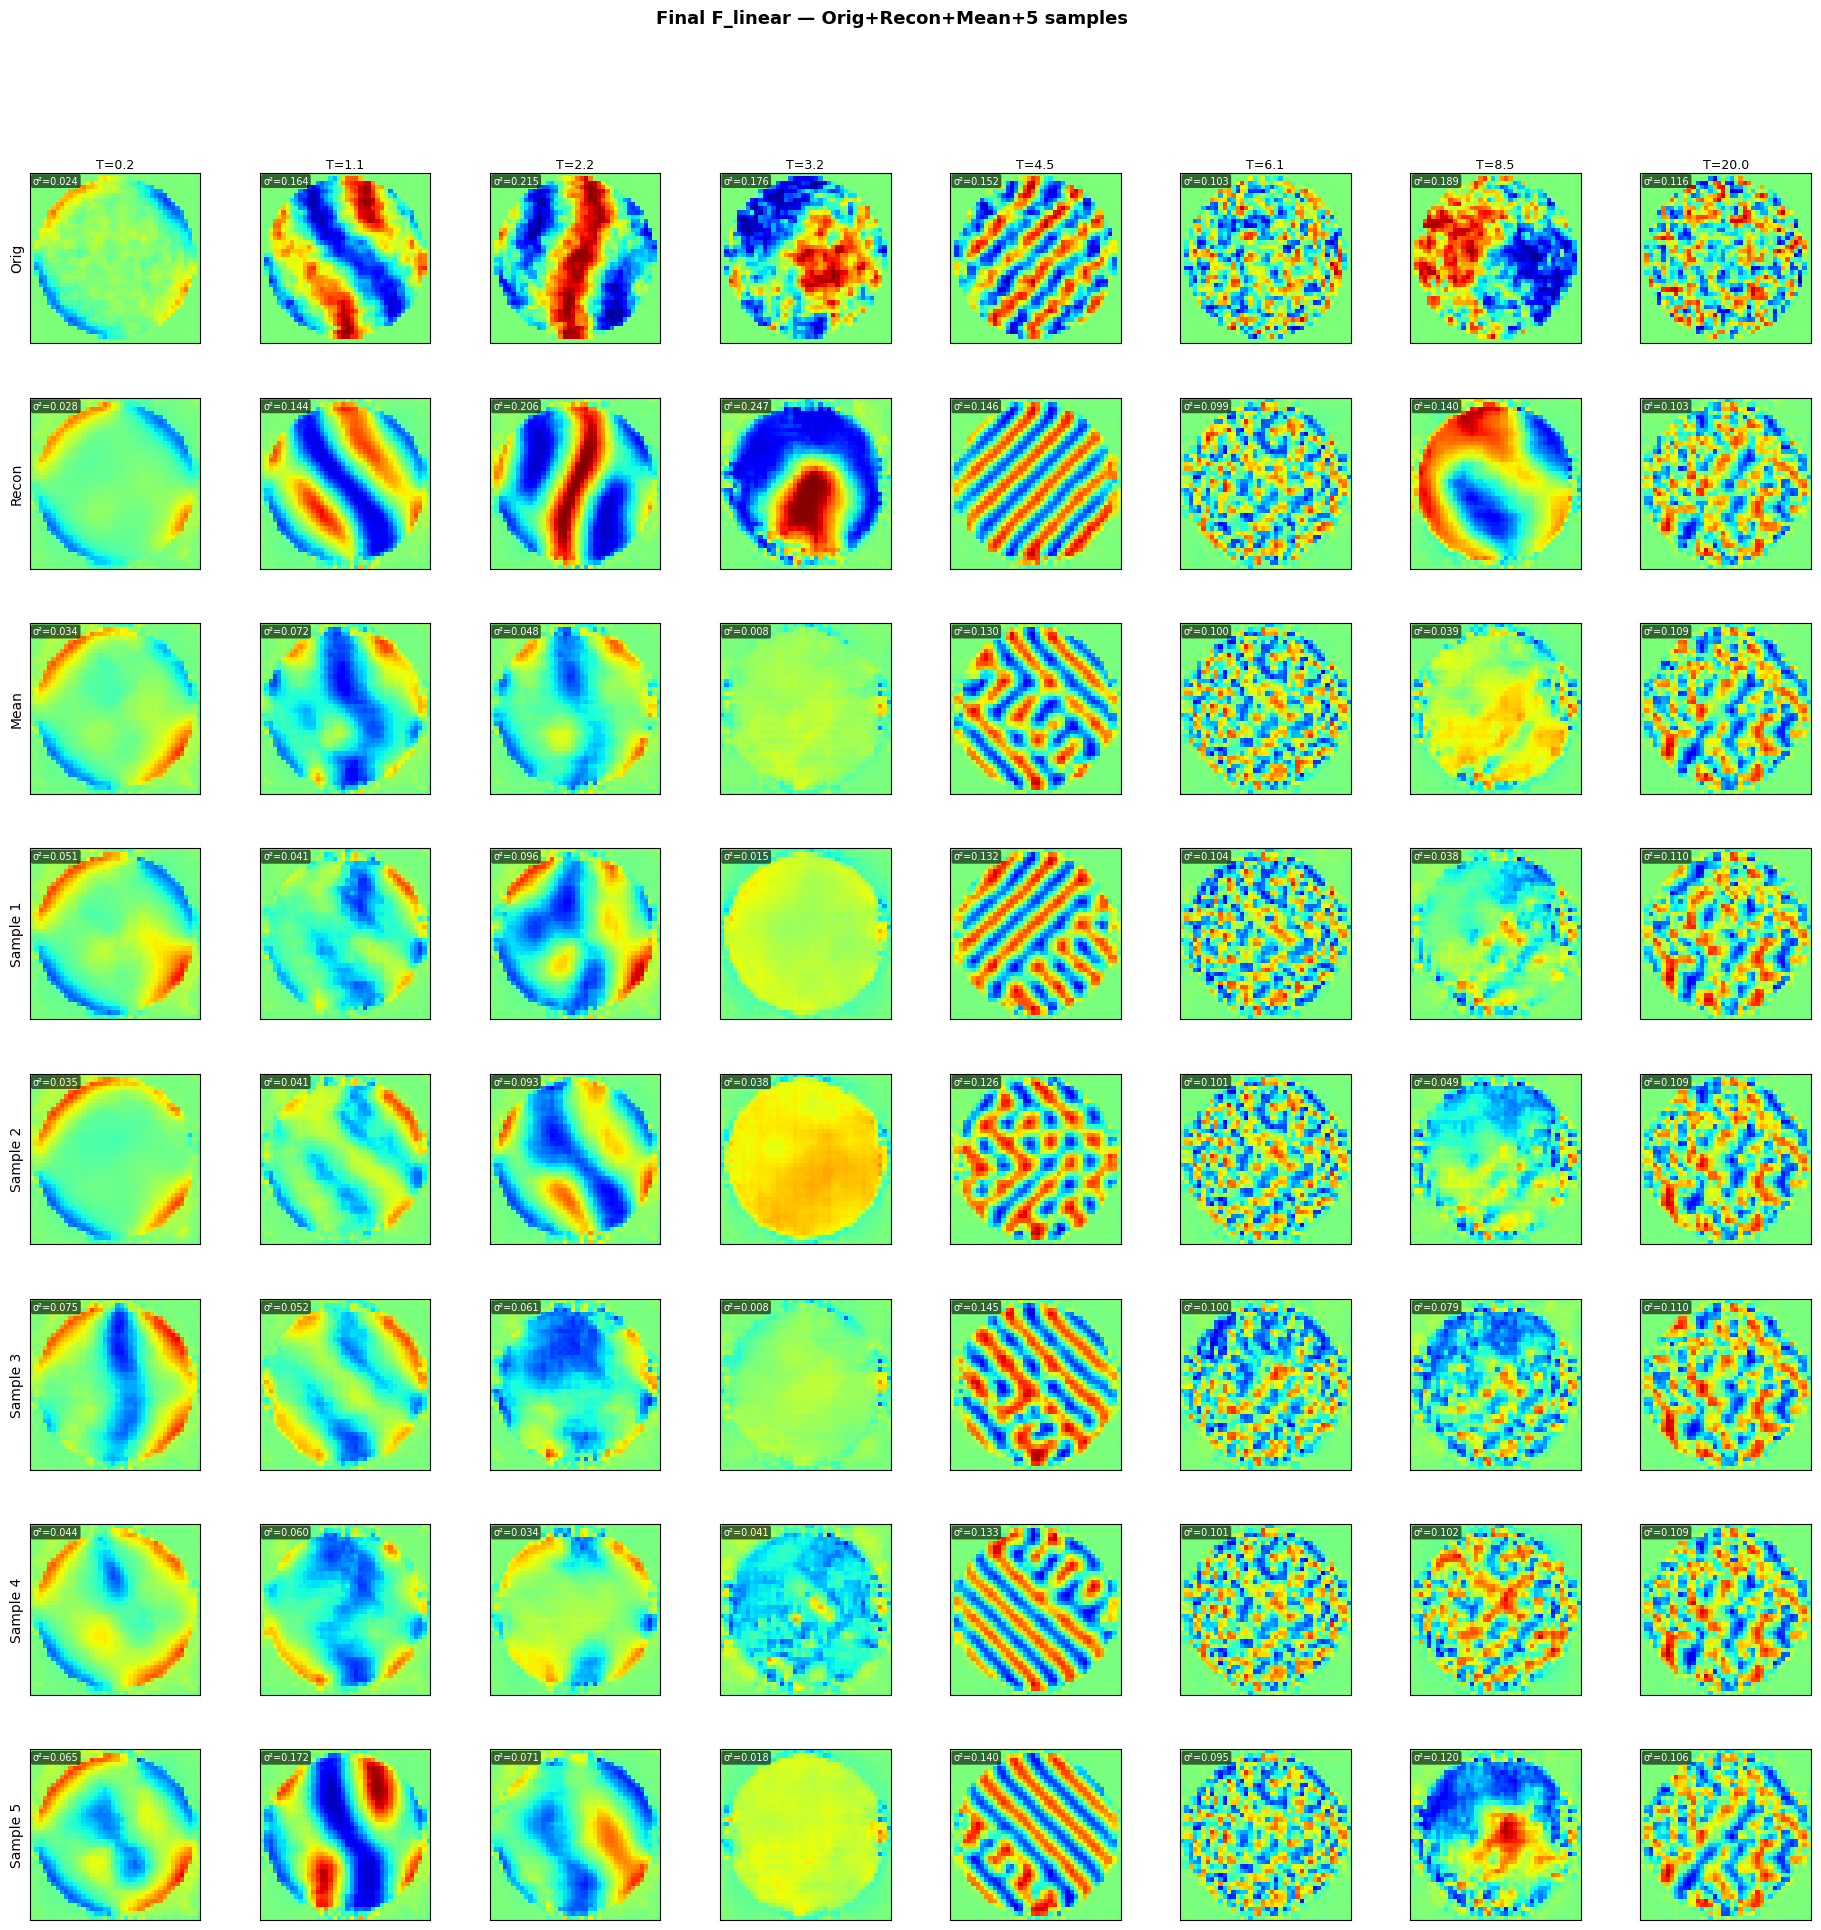

Saved /kaggle/working/grid_final_F_linear.png


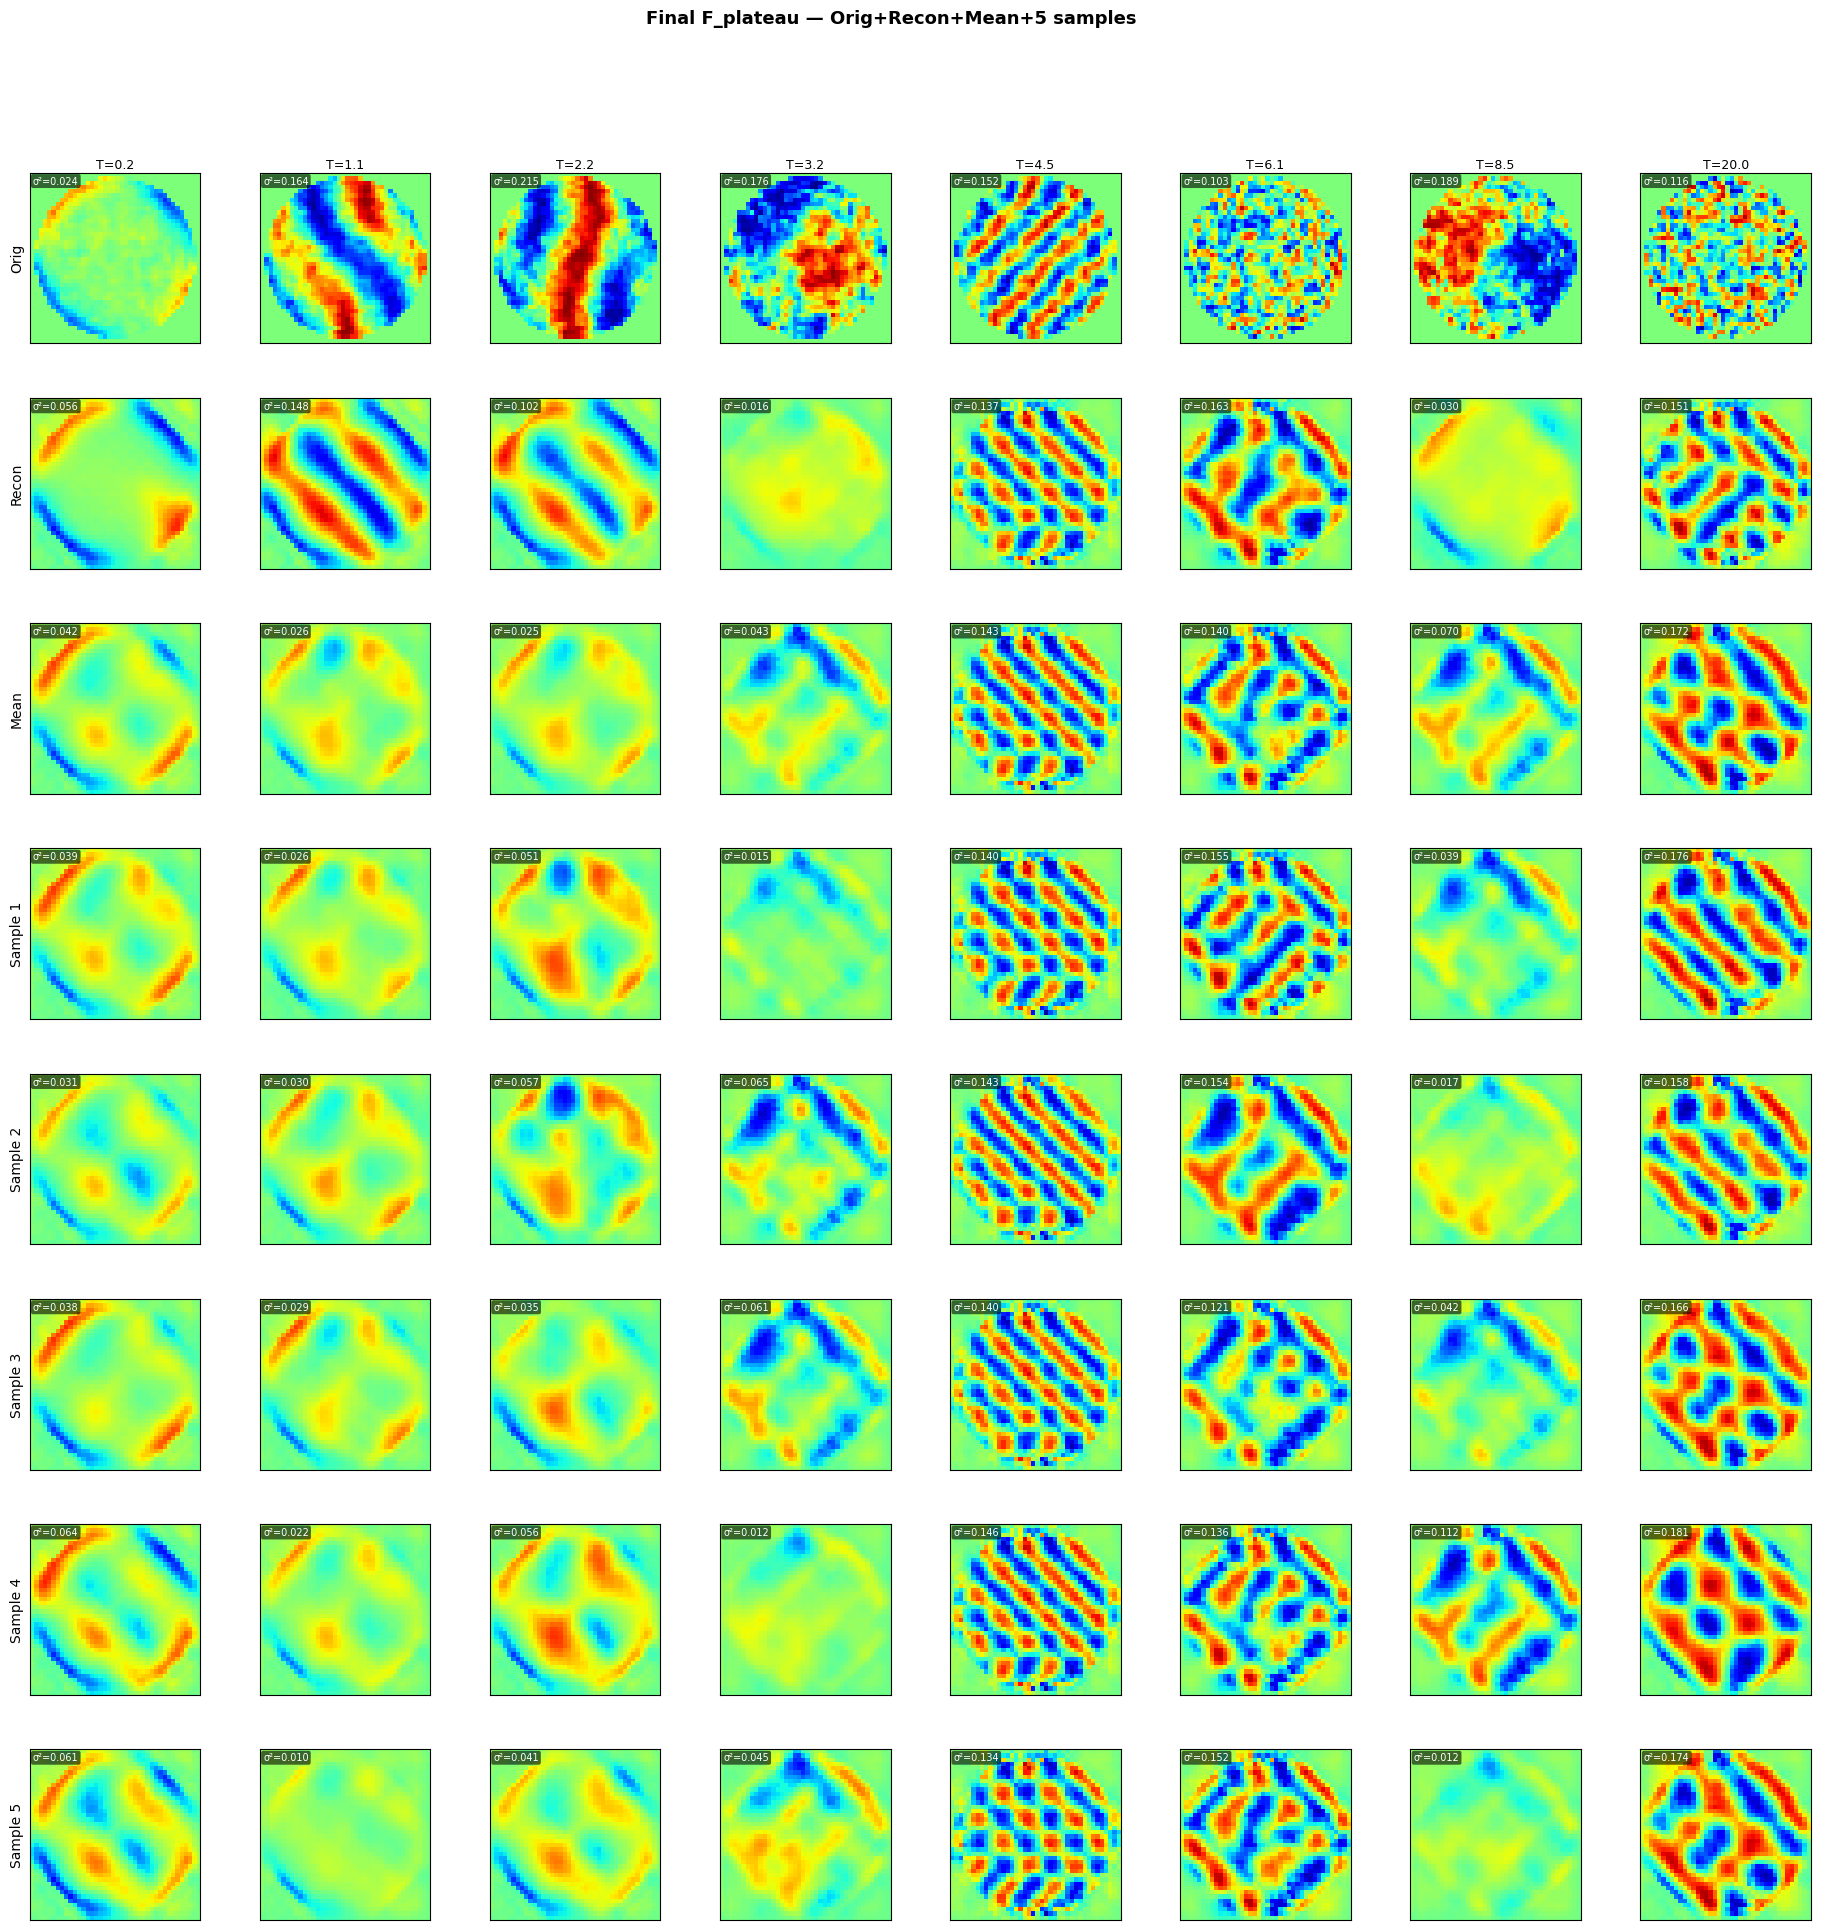

Saved /kaggle/working/grid_final_F_plateau.png


In [11]:
def grid_full(tag, z_dim, cond_emb_dim, sel_idx, n_samples=5):
    weights_path = os.path.join(OUT_DIR, f"weights_best_{tag}.weights.h5")
    if not os.path.exists(weights_path):
        print(f"[{tag}] no hay pesos best, omito")
        return None

    model = build_eval_model(z_dim, cond_emb_dim)
    model.load_weights(weights_path)

    n_show = len(sel_idx)
    n_rows = 3 + n_samples  # Orig + Recon + Mean + N samples
    fig = plt.figure(figsize=(2.4 * n_show, 2.4 * n_rows + 0.6))
    gs = plt.GridSpec(n_rows, n_show, figure=fig, wspace=0.08, hspace=0.32,
                      left=0.04, right=0.99, top=1.0 - 0.7/n_rows, bottom=0.03)

    row_labels = ["Orig", "Recon", "Mean"] + [f"Sample {i+1}" for i in range(n_samples)]

    for col, si in enumerate(sel_idx):
        img_raw = imgs_val[si:si+1]
        y_in = params_val[si:si+1]
        T_orig = params_val_raw[si, 0]

        img_40 = tf.image.resize(img_raw, (40, 40)).numpy()
        img_vit = tf.image.grayscale_to_rgb(tf.image.resize(img_raw, (224, 224)))

        x_hat, *_ = model([img_vit, y_in], training=False)
        x_mean = model.generate_mean(y_in).numpy()
        samples = [model.generate(y_in).numpy() for _ in range(n_samples)]

        rows = ([img_40[0,:,:,0], x_hat.numpy()[0,:,:,0], x_mean[0,:,:,0]] +
                [s[0,:,:,0] for s in samples])
        vars_ = [float(np.var(r)) for r in rows]

        for row, (im, lb, vv) in enumerate(zip(rows, row_labels, vars_)):
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(im, cmap="jet", vmin=-1, vmax=1, interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(lb, fontsize=10)
            if row == 0:
                ax.set_title(f"T={T_orig:.1f}", fontsize=9, pad=3)
            ax.text(0.02, 0.98, f"σ²={vv:.3f}", transform=ax.transAxes,
                    fontsize=7, color="white", verticalalignment="top",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6, edgecolor="none"))

    fig.suptitle(f"Final {tag} — Orig+Recon+Mean+{n_samples} samples", fontsize=13, fontweight="bold", y=0.995)
    out_png = f"/kaggle/working/grid_final_{tag}.png"
    plt.savefig(out_png, dpi=100); plt.show()
    print(f"Saved {out_png}")

    del model
    keras.backend.clear_session()
    import gc; gc.collect()


grid_full("F_linear",  BASE["z_dim"], BASE["cond_emb_dim"], sel_idx, n_samples=5)
grid_full("F_plateau", BASE["z_dim"], BASE["cond_emb_dim"], sel_idx, n_samples=5)

## Resumen final

In [12]:
print("="*70); print("RESUMEN FINAL"); print("="*70)
for tag in ["F_linear", "F_plateau"]:
    sp = os.path.join(OUT_DIR, f"status_{tag}.json")
    hp = os.path.join(OUT_DIR, f"history_{tag}.json")
    if os.path.exists(sp):
        with open(sp) as f: s = json.load(f)
        print(f"\n[{tag}]"); print(f"  status: {s['status']}")
        print(f"  best_val_gen_sample: {s.get('best_val_gen')}")
        if os.path.exists(hp):
            with open(hp) as f: hist = json.load(f)
            if hist:
                last = hist[-1]
                print(f"  last epoch: {last['epoch']}")
                print(f"    val_recon            = {last['val_recon']:.4f}")
                print(f"    val_gen_sample       = {last['val_gen_sample']:.4f}  (con sampling)")
                print(f"    val_gen_mean         = {last['val_gen_mean']:.4f}    (z=mu_p)")
                print(f"    val_var_real         = {last['val_var_real']:.4f}    ← objetivo")
                print(f"    val_var_recon        = {last['val_var_recon']:.4f}")
                print(f"    val_var_gen_sample   = {last['val_var_gen_sample']:.4f}    ← clave")
                print(f"    val_var_gen_mean     = {last['val_var_gen_mean']:.4f}")
                print(f"    val_patch_var_loss   = {last['val_patch_var_loss_gen']:.4f}")
                print(f"    kl_active            = {last['kl_active']:.2f}")
                print(f"    var_q                = {last['var_q']:.3f}")

print("\n" + "="*70)
print("Archivos en", OUT_DIR)
for f in sorted(os.listdir(OUT_DIR)):
    sz = os.path.getsize(os.path.join(OUT_DIR, f)) / 1024
    print(f"  {f:48s} {sz:10.1f} KB")

RESUMEN FINAL

[F_linear]
  status: ok
  best_val_gen_sample: 0.8795198537770984
  last epoch: 30
    val_recon            = 0.5314
    val_gen_sample       = 0.8823  (con sampling)
    val_gen_mean         = 0.8608    (z=mu_p)
    val_var_real         = 0.1107    ← objetivo
    val_var_recon        = 0.1109
    val_var_gen_sample   = 0.0970    ← clave
    val_var_gen_mean     = 0.0895
    val_patch_var_loss   = 0.0022
    kl_active            = 1.00
    var_q                = 1.245

[F_plateau]
  status: ok
  best_val_gen_sample: 0.8512639675325561
  last epoch: 30
    val_recon            = 0.5325
    val_gen_sample       = 0.8714  (con sampling)
    val_gen_mean         = 0.8413    (z=mu_p)
    val_var_real         = 0.1107    ← objetivo
    val_var_recon        = 0.1110
    val_var_gen_sample   = 0.0959    ← clave
    val_var_gen_mean     = 0.0861
    val_patch_var_loss   = 0.0022
    kl_active            = 1.00
    var_q                = 0.726

Archivos en /kaggle/working/final_ru